DATASET SHAPE:
(522, 15)

FIRST 5 ROWS:
   Year        T2M       RH2M  PRECTOTCORR District_Name      NDVI     Yield  \
0  2016  26.953716  42.146858       771.76          agra  0.349721  2.769919   
1  2017  27.219096  39.360767       454.06          agra  0.297969  3.153938   
2  2018  26.341507  46.327671       857.98          agra  0.387408  3.292996   
3  2019  26.030219  50.758603       698.90          agra  0.305234  3.182999   
4  2020  26.196694  46.162268       510.40          agra  0.336999  3.703480   

   Temp_Anomaly  Rain_Anomaly  Humidity_Anomaly  Climate_Anomaly_Score  \
0      1.131511   -186.414079        -10.907615              13.903267   
1      1.396891   -504.114079        -13.693705              20.131737   
2      0.519302   -100.194079         -6.726801               8.248044   
3      0.208015   -259.274079         -2.295870               5.096625   
4      0.374489   -447.774079         -6.892205              11.744435   

   Previous_Year_Yield  Rolling_Te

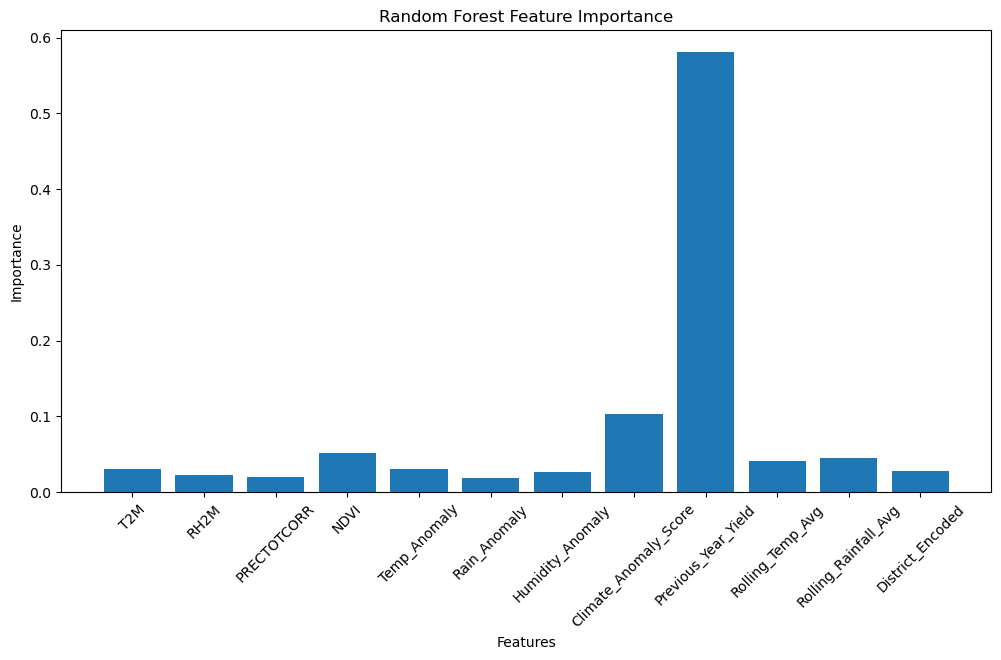

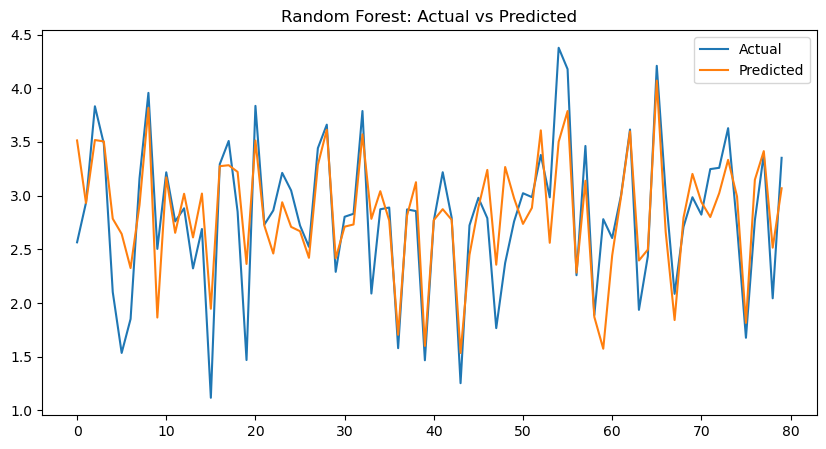

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt


# ==========================================
# LOAD FEATURE ENGINEERED DATASET
# ==========================================

df = pd.read_csv(
    "../datasets/feature_engineered_dataset.csv"
)

print("DATASET SHAPE:")
print(df.shape)

print("\nFIRST 5 ROWS:")
print(df.head())


# ==========================================
# FEATURES
# ==========================================

X = df[[
    'T2M',
    'RH2M',
    'PRECTOTCORR',
    'NDVI',

    'Temp_Anomaly',
    'Rain_Anomaly',
    'Humidity_Anomaly',

    'Climate_Anomaly_Score',

    'Previous_Year_Yield',

    'Rolling_Temp_Avg',
    'Rolling_Rainfall_Avg',

    'District_Encoded'
]]

# TARGET
y = df['Yield']


# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print("\nTRAIN SIZE:", len(X_train))
print("TEST SIZE:", len(X_test))


# ==========================================
# MODELS
# ==========================================

models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0
    )

}


# ==========================================
# RESULTS STORAGE
# ==========================================

results = []

best_model = None
best_r2 = -999


# ==========================================
# TRAIN MODELS
# ==========================================

for name, model in models.items():

    print("\n===================================")
    print("TRAINING:", name)
    print("===================================")

    # TRAIN
    model.fit(X_train, y_train)

    # PREDICT
    preds = model.predict(X_test)

    # METRICS
    mae = mean_absolute_error(y_test, preds)

    rmse = np.sqrt(
        mean_squared_error(y_test, preds)
    )

    r2 = r2_score(y_test, preds)

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

    # SAVE
    results.append([
        name,
        mae,
        rmse,
        r2
    ])

    # BEST MODEL
    if r2 > best_r2:

        best_r2 = r2
        best_model = model
        best_name = name


# ==========================================
# RESULTS TABLE
# ==========================================

results_df = pd.DataFrame(

    results,

    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2'
    ]

)

print("\nFINAL RESULTS:")
print(results_df)


# ==========================================
# SAVE RESULTS
# ==========================================

results_df.to_csv(

    "../results/advanced_model_results.csv",

    index=False

)

print("\nADVANCED MODEL RESULTS SAVED!")


# ==========================================
# BEST MODEL
# ==========================================

print("\nBEST MODEL:")
print(best_name)

print("BEST R2:")
print(best_r2)


# ==========================================
# FEATURE IMPORTANCE
# ==========================================

if hasattr(best_model, 'feature_importances_'):

    importance = best_model.feature_importances_

    features = X.columns

    plt.figure(figsize=(12,6))

    plt.bar(
        features,
        importance
    )

    plt.xticks(rotation=45)

    plt.title(
        f"{best_name} Feature Importance"
    )

    plt.xlabel("Features")
    plt.ylabel("Importance")

    plt.show()


# ==========================================
# ACTUAL VS PREDICTED
# ==========================================

best_preds = best_model.predict(X_test)

plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:80],
    label='Actual'
)

plt.plot(
    best_preds[:80],
    label='Predicted'
)

plt.title(
    f"{best_name}: Actual vs Predicted"
)

plt.legend()

plt.show()